Wykrywanie anomalii w dźwiękach maszynowych

Wykonał: Mikołaj Zuziak

In [1]:
%pip install librosa soundfile audiomentations tqdm pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display
import soundfile as sf

Dataset params

In [3]:
DATASET_ROOT = Path("./dataset")

MACHINE_TYPES = ["fan"] # For now we use only ther 6db fan dataset (over 12GB of recordings)
CONDITIONS    = ["normal", "abnormal"]

Audio params

In [4]:
SAMPLE_RATE   = 16_000
CLIP_DURATION = 10
N_MELS        = 128
N_FFT         = 1024
HOP_LENGTH    = 512
N_MFCC        = 40

In [5]:
print("Config loaded.")
print(f"Looking for data in: {DATASET_ROOT.resolve()}")
print(f"Folders found: {[d.name for d in DATASET_ROOT.iterdir() if d.is_dir()]}")

Config loaded.
Looking for data in: D:\Github\UBB-MGR-Sem3\Przemysl\dataset
Folders found: ['fan']


Dateset DF building

In [6]:
records = []

for machine_dir in sorted(DATASET_ROOT.iterdir()):
    if not machine_dir.is_dir():
        continue

    machine_type = machine_dir.name   # "fan", "pump", etc.

    if machine_type not in MACHINE_TYPES:
        print(f"  Skipping unrecognised folder: {machine_type}")
        continue

    for id_dir in sorted(machine_dir.iterdir()):
        if not id_dir.is_dir():
            continue

        machine_id = id_dir.name   # "id_00", "id_02", etc.

        for condition in CONDITIONS:
            cond_dir = id_dir / condition
            if not cond_dir.exists():
                continue

            wav_files = sorted(cond_dir.glob("*.wav"))

            for wav_file in wav_files:
                records.append({
                    "path":         str(wav_file),
                    "machine_type": machine_type,
                    "machine_id":   machine_id,
                    "condition":    condition,
                    "label":        0 if condition == "normal" else 1,
                    "filename":     wav_file.name,
                })

df = pd.DataFrame(records)

Dataset preview

In [7]:
print(f"Total files found: {len(df)}")

print("=== Files per machine type ===")
print(df.groupby(["machine_type", "machine_id", "condition"]).size().to_string())

print("\n=== Total per condition ===")
print(df.groupby("condition").size().to_string())

print("\n=== Machine IDs available ===")
print(df.groupby(["machine_type", "machine_id"]).size().reset_index(name="count").to_string(index=False))

Total files found: 8343
=== Files per machine type ===
machine_type  machine_id  condition
fan           id_00_-6db  abnormal      407
                          normal       1011
              id_00_0db   abnormal      407
                          normal       1011
              id_02_-6db  abnormal      359
                          normal       1016
              id_02_0db   abnormal      359
                          normal       1016
              id_04_0db   abnormal      348
                          normal       1033
              id_06_0db   abnormal      361
                          normal       1015

=== Total per condition ===
condition
abnormal    2241
normal      6102

=== Machine IDs available ===
machine_type machine_id  count
         fan id_00_-6db   1418
         fan  id_00_0db   1418
         fan id_02_-6db   1375
         fan  id_02_0db   1375
         fan  id_04_0db   1381
         fan  id_06_0db   1376


Class distribution in the dataset

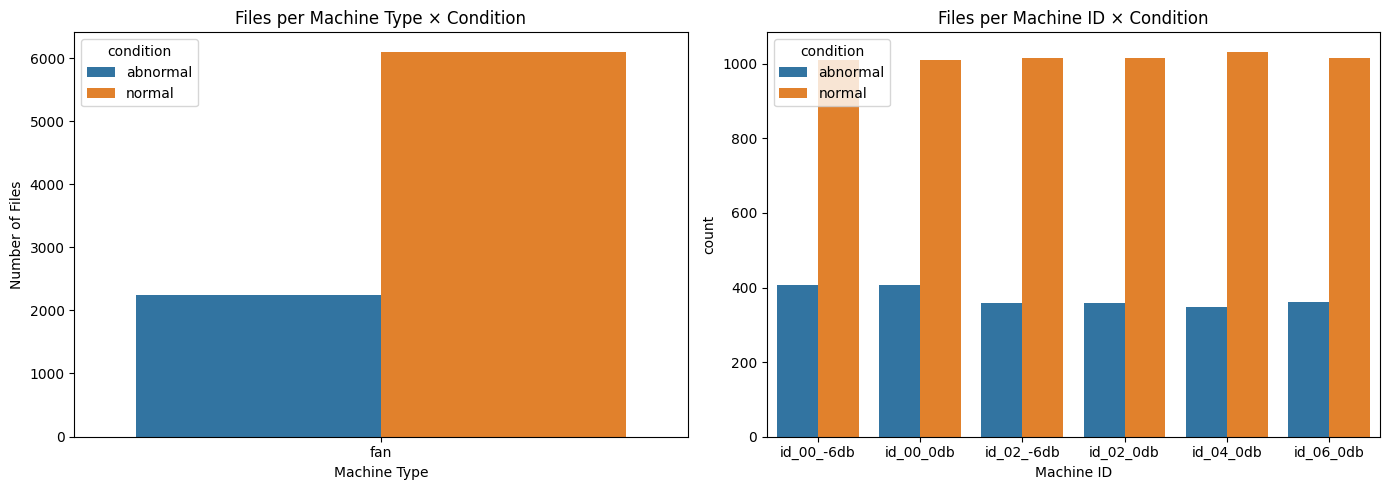

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Files per machine type x condition
counts = df.groupby(["machine_type", "condition"]).size().reset_index(name="count")
sns.barplot(data=counts, x="machine_type", y="count", hue="condition", ax=axes[0])
axes[0].set_title("Files per Machine Type × Condition")
axes[0].set_xlabel("Machine Type")
axes[0].set_ylabel("Number of Files")

# Files per machine ID x condition (useful to spot imbalances within a machine type)
id_counts = df.groupby(["machine_id", "condition"]).size().reset_index(name="count")
sns.barplot(data=id_counts, x="machine_id", y="count", hue="condition", ax=axes[1])
axes[1].set_title("Files per Machine ID × Condition")
axes[1].set_xlabel("Machine ID")

plt.tight_layout()
plt.savefig("dataset_distribution.png", dpi=150)
plt.show()

In [9]:
def load_audio(path: str, sr: int = SAMPLE_RATE, duration: float = CLIP_DURATION) -> np.ndarray:
    """
    Load a .wav file, resample to `sr`, and fix length to `duration` seconds.
    Returns a 1D numpy array of float32 samples.
    """
    wav, orig_sr = librosa.load(path, sr=sr, mono=True)

    target_len = int(sr * duration)

    if len(wav) < target_len:
        wav = np.pad(wav, (0, target_len - len(wav)))   # pad with silence
    else:
        wav = wav[:target_len]                           # trim

    return wav.astype(np.float32)


sample_path = df.iloc[0]["path"]
sample_wav  = load_audio(sample_path)

print(f"Loaded: {sample_path}")
print(f"Shape:  {sample_wav.shape}  ({sample_wav.shape[0] / SAMPLE_RATE:.1f}s @ {SAMPLE_RATE} Hz)")

d:\Github\UBB-MGR-Sem3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: dataset\fan\id_00_-6db\normal\00000000.wav
Shape:  (160000,)  (10.0s @ 16000 Hz)


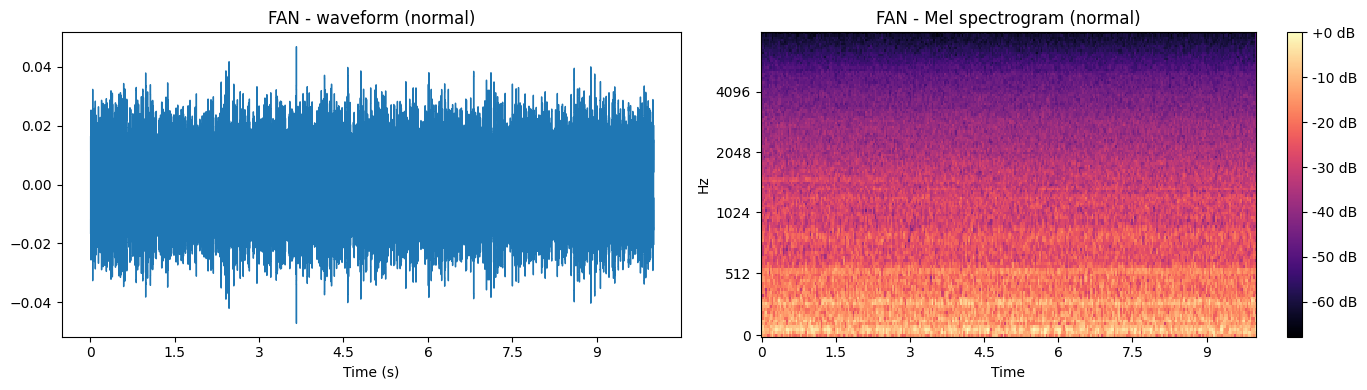

In [10]:
available_types = [m for m in MACHINE_TYPES if m in df["machine_type"].values]

fig, axes = plt.subplots(len(available_types), 2, figsize=(14, 4 * len(available_types)), squeeze=False)

for i, mtype in enumerate(available_types):
    subset = df[(df["machine_type"] == mtype) & (df["condition"] == "normal")]
    if subset.empty:
        continue

    wav = load_audio(subset.iloc[0]["path"])

    # --- Waveform ---
    ax_wave = axes[i][0]
    librosa.display.waveshow(wav, sr=SAMPLE_RATE, ax=ax_wave)
    ax_wave.set_title(f"{mtype.upper()} - waveform (normal)")
    ax_wave.set_xlabel("Time (s)")

    # --- Mel spectrogram ---
    ax_mel = axes[i][1]
    mel = librosa.feature.melspectrogram(y=wav, sr=SAMPLE_RATE,
                                         n_fft=N_FFT, hop_length=HOP_LENGTH,
                                         n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                                   x_axis="time", y_axis="mel", ax=ax_mel)
    fig.colorbar(img, ax=ax_mel, format="%+2.0f dB")
    ax_mel.set_title(f"{mtype.upper()} - Mel spectrogram (normal)")

plt.tight_layout()
plt.savefig("spectrograms_overview.png", dpi=150)
plt.show()

In [11]:
def extract_mfccs(wav: np.ndarray,
                  sr: int   = SAMPLE_RATE,
                  n_mfcc: int = N_MFCC) -> np.ndarray:
    """
    Returns a flat feature vector:
    mean + std of each MFCC coefficient over time → shape (n_mfcc * 2,)
    """
    mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=n_mfcc,
                                 n_fft=N_FFT, hop_length=HOP_LENGTH)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])


sample_features = extract_mfccs(sample_wav)
print(f"Feature vector shape: {sample_features.shape}")   # should be (80,) for n_mfcc=40

Feature vector shape: (80,)


In [12]:
FEATURES_CACHE = Path("features_cache.npz")

if FEATURES_CACHE.exists():
    print("Loading cached features...")
    cache       = np.load(FEATURES_CACHE, allow_pickle=True)
    X           = cache["X"]
    y_label     = cache["y_label"]
    y_machine   = cache["y_machine"]
    file_index  = cache["file_index"].tolist()
    print(f"Loaded {len(X)} samples from cache.")

else:
    print(f"Extracting features for {len(df)} files...")
    X, y_label, y_machine, file_index = [], [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            wav     = load_audio(row["path"])
            feats   = extract_mfccs(wav)
            X.append(feats)
            y_label.append(row["label"])                      # 0=normal, 1=anomalous
            y_machine.append(MACHINE_TYPES.index(row["machine_type"]))  # 0–3
            file_index.append(row["path"])
        except Exception as e:
            print(f"  Skipping {row['path']}: {e}")

    X         = np.array(X,         dtype=np.float32)
    y_label   = np.array(y_label,   dtype=np.int32)
    y_machine = np.array(y_machine, dtype=np.int32)

    np.savez(FEATURES_CACHE,
             X=X, y_label=y_label, y_machine=y_machine,
             file_index=np.array(file_index))
    print(f"Done. Feature matrix shape: {X.shape}")
    print(f"Saved to {FEATURES_CACHE}")

Extracting features for 8343 files...


100%|██████████| 8343/8343 [02:19<00:00, 59.89it/s]

Done. Feature matrix shape: (8343, 80)
Saved to features_cache.npz


In [13]:
print(f"Feature matrix X : {X.shape}")
print(f"Machine labels   : {np.bincount(y_machine)}  (fan, pump, slider, valve)")
print(f"Anomaly labels   : {np.bincount(y_label)}   (0=normal, 1=anomalous)")

# Check for NaN/Inf
print(f"\nNaN in X: {np.isnan(X).sum()}")
print(f"Inf in X: {np.isinf(X).sum()}")

# Feature distribution
print(f"\nFeature mean range: [{X.mean(axis=0).min():.2f}, {X.mean(axis=0).max():.2f}]")
print(f"Feature std  range: [{X.std(axis=0).min():.2f},  {X.std(axis=0).max():.2f}]")

Feature matrix X : (8343, 80)
Machine labels   : [8343]  (fan, pump, slider, valve)
Anomaly labels   : [6102 2241]   (0=normal, 1=anomalous)

NaN in X: 0
Inf in X: 0

Feature mean range: [-427.30, 111.80]
Feature std  range: [0.19,  44.43]


In [ ]:
df.to_csv("file_index.csv", index=False)
print("Saved file_index.csv")
print(df.dtypes)
print(df.head())

Saved file_index.csv
path              str
machine_type      str
machine_id        str
condition         str
label           int64
filename          str
dtype: object
                                         path machine_type  machine_id  \
0  dataset\fan\id_00_-6db\normal\00000000.wav          fan  id_00_-6db   
1  dataset\fan\id_00_-6db\normal\00000001.wav          fan  id_00_-6db   
2  dataset\fan\id_00_-6db\normal\00000002.wav          fan  id_00_-6db   
3  dataset\fan\id_00_-6db\normal\00000003.wav          fan  id_00_-6db   
4  dataset\fan\id_00_-6db\normal\00000004.wav          fan  id_00_-6db   

  condition  label      filename  
0    normal      0  00000000.wav  
1    normal      0  00000001.wav  
2    normal      0  00000002.wav  
3    normal      0  00000003.wav  
4    normal      0  00000004.wav  
